# Safety: keep-out zones, passive safety, and approach corridors

Layer 2 of this package is about mission safety: making sure a planned approach not only works, but fails gracefully, and respects the geometric constraints a real operation would impose. This notebook builds the first three pieces of that layer, on top of the relative-motion tools from `cw_fundamentals.ipynb`.

A keep-out zone is a region around the chief that no planned trajectory should ever enter: the first thing any safety check needs is a way to say whether a given relative trajectory stays outside it. Passive safety asks a sharper question about any planned burn: if that burn simply fails to fire, does the deputy coast on harmlessly, or does it drift into the keep-out zone before anyone can react? An approach corridor adds a directional constraint on top of the distance one: not just "far enough", but "coming from the right direction", typically a cone around the V-bar or the R-bar.

The three checks are independent of each other, and the last section shows this directly: the same two example maneuvers pass one check and fail another, which is exactly why a real feasibility analysis needs all three, not just one of them.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from ios_mission_planner.dynamics.relative.hill import hill_equations_symbolic
from ios_mission_planner.dynamics.relative.cw import cw_targeting
from ios_mission_planner.dynamics.relative.relative_orbit import RelativeOrbit, state_from_relative_orbit
from ios_mission_planner.propagation.heyoka_propagator import propagate
from ios_mission_planner.safety.keepout import KeepOutEllipsoid, check_trajectory
from ios_mission_planner.safety.passive_safety import check_passive_safety
from ios_mission_planner.safety.corridor import ApproachCorridor, check_corridor

mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.3, "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})

COL_ANA = "#1f77b4"
COL_NUM = "#d62728"
COL_CHIEF = "#2ca02c"
COL_ZONE = "#9467bd"
COL_CORRIDOR = "#ff7f0e"

## Setup

Same chief as the other notebooks: a circular low Earth orbit at 500 km altitude. The `fly` helper is the same impulse-and-coast integrator used in `cw_fundamentals.ipynb`, kept local to this notebook since it is a thin convenience around `propagate`, not a reusable package function.

In [2]:
mu_earth = 398600.4418
alt = 500.0
a = 6378.137 + alt
n = np.sqrt(mu_earth / a**3)
T = 2 * np.pi / n


def fly(state0, plan, n, pts=400):
    """Integrate a sequence of (impulse, coast duration) pairs with heyoka."""
    state = np.array(state0, dtype=float)
    t_start = 0.0
    times, states = [], []

    for dv, duration in plan:
        state[3:] += dv
        t_eval = np.linspace(0.0, duration, pts)
        leg = propagate(hill_equations_symbolic(), state, t_eval, pars=[n])
        times.append(t_start + t_eval)
        states.append(leg.y.T)
        state = leg.y[:, -1].copy()
        t_start += duration

    return np.concatenate(times), np.vstack(states)

## Part A: keep-out zones

A keep-out zone here is an ellipsoid centred on the chief, `KeepOutEllipsoid(a, b, c)`, with semi-axes along radial, along-track and cross-track. A relative position violates it when $(x/a)^2+(y/b)^2+(z/c)^2 < 1$, so a sphere is just the special case $a=b=c$. `check_trajectory` evaluates this along an entire relative trajectory and reports whether it was ever violated and by how much.

As a first check, take the 2:1 safety ellipse from `cw_fundamentals.ipynb`, with $\rho=100$ m. Its closest approach to the chief is exactly $\rho$, reached at the two points where it crosses the radial axis, so a zone smaller than 100 m should never be violated and one larger than 100 m always will be.

20 m zone  : violated=False,  margin=-4.000
150 m zone : violated=True, margin=0.333


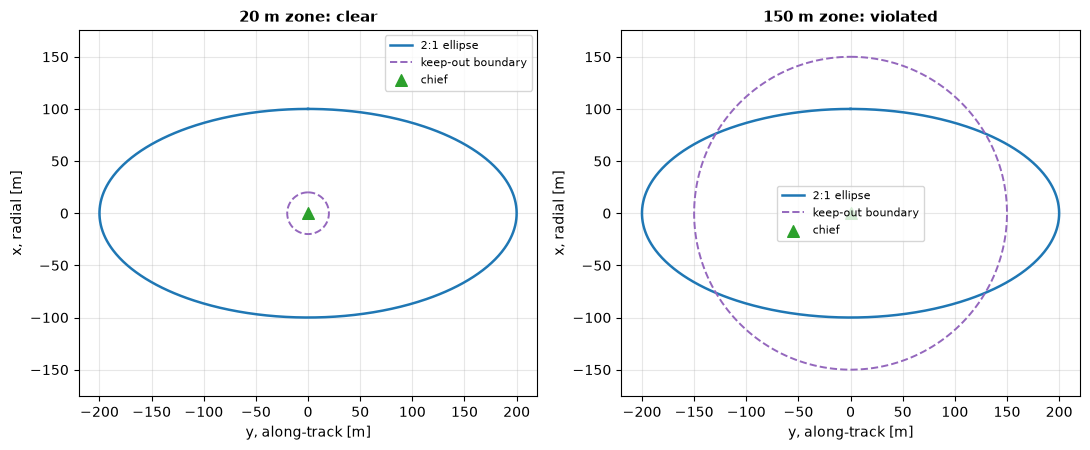

In [3]:
safety_orbit = RelativeOrbit(x_off=0.0, y_c=0.0, rho=100.0, alpha=0.0)
state0 = state_from_relative_orbit(safety_orbit, n)
t = np.linspace(0, T, 800)
ellipse = propagate(hill_equations_symbolic(), state0, t, pars=[n]).y.T

zone_safe = KeepOutEllipsoid(a=20.0, b=20.0, c=20.0)
zone_tight = KeepOutEllipsoid(a=150.0, b=150.0, c=150.0)

v_safe, m_safe, _ = check_trajectory(ellipse[:, :3], zone_safe)
v_tight, m_tight, _ = check_trajectory(ellipse[:, :3], zone_tight)

print(f"20 m zone  : violated={v_safe},  margin={m_safe:.3f}")
print(f"150 m zone : violated={v_tight}, margin={m_tight:.3f}")


def circle(radius, n_pts=200):
    phi = np.linspace(0, 2 * np.pi, n_pts)
    return radius * np.cos(phi), radius * np.sin(phi)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))

for ax, zone, label in zip(axes, [zone_safe, zone_tight], ["20 m zone: clear", "150 m zone: violated"]):
    cx, cy = circle(zone.a)
    ax.plot(ellipse[:, 1], ellipse[:, 0], color=COL_ANA, lw=1.8, label="2:1 ellipse")
    ax.plot(cy, cx, color=COL_ZONE, lw=1.4, ls="--", label="keep-out boundary")
    ax.scatter([0], [0], color=COL_CHIEF, marker="^", s=70, zorder=5, label="chief")
    ax.set_xlabel("y, along-track [m]"); ax.set_ylabel("x, radial [m]")
    ax.set_title(label)
    ax.set_aspect("equal", adjustable="datalim")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Part B: passive safety

Passive safety asks what happens if a planned burn simply does not fire. `check_passive_safety(state_before_burn, n, zone, duration)` coasts the relative state right before the burn forward for `duration`, as a free ballistic trajectory, and checks it against a keep-out zone: the burn is passively safe when that coast never enters the zone within the given time, which is the time available to notice the failure and react.

Two example two-impulse hops from the same 1 km hold point make the point concrete. The cautious one targets a hold point 30 m from the chief over half an orbit; the aggressive one targets 15 m over a fifth of an orbit, closer and faster. Both are perfectly good targeting solutions on their own, in the sense that they reach their target; what passive safety asks is what happens to the second burn specifically, since that is the one that is supposed to stop the deputy right next to the chief.

In [4]:
r0 = np.array([0.0, -1000.0, 0.0])
v0 = np.zeros(3)
zone = KeepOutEllipsoid(a=20.0, b=20.0, c=20.0)

hops = {
    "cautious (30 m, 0.5 orbit)": (np.array([0.0, -30.0, 0.0]), 0.5 * T),
    "aggressive (15 m, 0.2 orbit)": (np.array([0.0, -15.0, 0.0]), 0.2 * T),
}

burns, failures = {}, {}
for label, (rf, tof) in hops.items():
    dv1, dv2 = cw_targeting(r0, v0, rf, np.zeros(3), tof, n)
    state_before_burn2 = np.concatenate([rf, -dv2])   # velocity on arrival, before the stopping burn
    violated, margin, t_fail, states_fail = check_passive_safety(state_before_burn2, n, zone, duration=T)
    burns[label] = (dv1, dv2, tof)
    failures[label] = (violated, margin, t_fail, states_fail)
    print(f"{label:30s} dv1={np.linalg.norm(dv1):.4f} dv2={np.linalg.norm(dv2):.4f} m/s   "
          f"burn-2 failure: violated={violated}, margin={margin:+.3f}")

cautious (30 m, 0.5 orbit)     dv1=0.2684 dv2=0.2684 m/s   burn-2 failure: violated=False, margin=-0.500
aggressive (15 m, 0.2 orbit)   dv1=0.9415 dv2=0.9415 m/s   burn-2 failure: violated=True, margin=+0.326


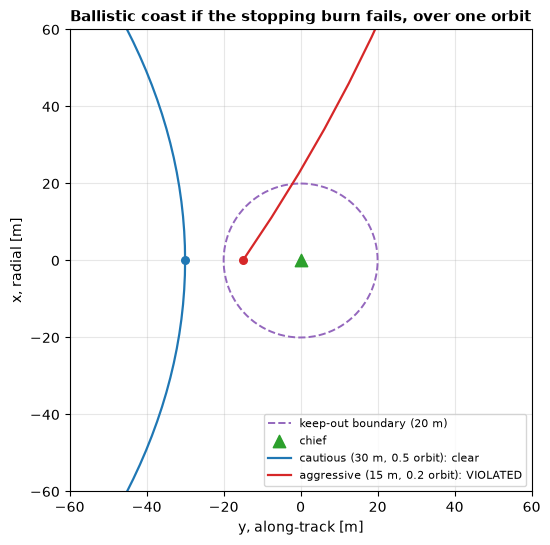

In [5]:
cx, cy = circle(zone.a)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(cy, cx, color=COL_ZONE, lw=1.4, ls="--", label="keep-out boundary (20 m)")
ax.scatter([0], [0], color=COL_CHIEF, marker="^", s=80, zorder=5, label="chief")

colors = [COL_ANA, COL_NUM]
for (label, (violated, margin, t_fail, states_fail)), c in zip(failures.items(), colors):
    ax.plot(states_fail[:, 1], states_fail[:, 0], color=c, lw=1.6,
             label=f"{label}: {'VIOLATED' if violated else 'clear'}")
    ax.scatter([states_fail[0, 1]], [states_fail[0, 0]], color=c, s=30, zorder=5)

ax.set_xlabel("y, along-track [m]"); ax.set_ylabel("x, radial [m]")
ax.set_title("Ballistic coast if the stopping burn fails, over one orbit")
ax.set_xlim(-60, 60); ax.set_ylim(-60, 60)
ax.set_aspect("equal", adjustable="box")
ax.legend(fontsize=8)
plt.show()

The aggressive hop fails the check: without its stopping burn, the deputy's leftover velocity carries it into the 20 m zone. The cautious one stays outside, though not by much, which is itself useful information: it says the 30 m, half-orbit design has little margin to spare, not that it is free to be made more aggressive.

## Part C: approach corridors

`ApproachCorridor(direction, half_angle)` defines a cone around a reference direction, typically the V-bar (`[0, -1, 0]`, approaching from behind) or the R-bar. `check_corridor` reports whether a trajectory ever strays outside that cone, and by how much at its worst.

The same two hops are checked again, this time on the transfer itself rather than on a burn failure, against a 45 degree corridor around the V-bar.

In [6]:
corridor = ApproachCorridor(direction=[0.0, -1.0, 0.0], half_angle=np.deg2rad(45.0))

transfers = {}
for label, (rf, tof) in hops.items():
    dv1, dv2 = cw_targeting(r0, v0, rf, np.zeros(3), tof, n)
    t_tr, y_tr = fly(np.concatenate([r0, v0]), [(dv1, tof)], n)
    transfers[label] = y_tr
    violated, margin, _ = check_corridor(y_tr[:, :3], corridor)
    print(f"{label:30s} corridor: violated={violated}, margin={margin:+.3f} rad "
          f"({np.degrees(margin):+.1f} deg)")

cautious (30 m, 0.5 orbit)     corridor: violated=True, margin=+0.165 rad (+9.5 deg)
aggressive (15 m, 0.2 orbit)   corridor: violated=False, margin=-0.034 rad (-1.9 deg)


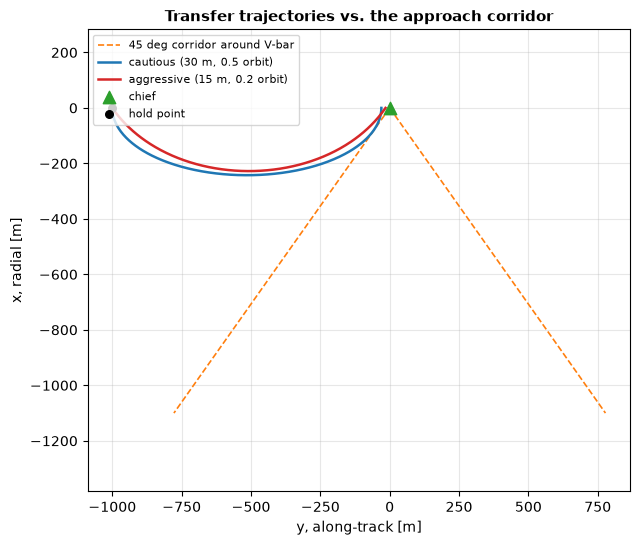

In [7]:
ray_length = 1100.0
half_angle = corridor.half_angle
ray_x = ray_length * np.sin(half_angle)

fig, ax = plt.subplots(figsize=(7, 6))
for sign in (-1, 1):
    ax.plot([0, sign * ray_x], [0, -ray_length], color=COL_CORRIDOR, lw=1.2, ls="--")
ax.plot([], [], color=COL_CORRIDOR, lw=1.2, ls="--", label="45 deg corridor around V-bar")

for (label, y_tr), c in zip(transfers.items(), colors):
    ax.plot(y_tr[:, 1], y_tr[:, 0], color=c, lw=1.8, label=label)
ax.scatter([0], [0], color=COL_CHIEF, marker="^", s=80, zorder=5, label="chief")
ax.scatter([-1000], [0], color="k", s=30, zorder=5, label="hold point")

ax.set_xlabel("y, along-track [m]"); ax.set_ylabel("x, radial [m]")
ax.set_title("Transfer trajectories vs. the approach corridor")
ax.set_aspect("equal", adjustable="datalim")
ax.legend(fontsize=8, loc="upper left")
plt.show()

Here the verdicts flip. The cautious hop leaves the corridor around the midpoint of its transfer: the same radial bow seen in `cw_fundamentals.ipynb`, caused by the Coriolis-like coupling between along-track and radial motion, swings it momentarily outside a 45 degree cone even though it starts and ends right on the V-bar. The aggressive hop, shorter and more direct, stays inside.

Passive safety and corridor compliance are therefore not two readings of the same thing: the cautious hop is passively safe but briefly off-corridor, the aggressive one is on-corridor but passively unsafe. A real feasibility check has to run both, because either one by itself would have cleared a maneuver that the other flags.

## Part D: J2 drift and a station-keeping budget

The 2:1 ellipse is drift-free only in the linear, unperturbed CW model. `rendezvous_to_safety_ellipse.ipynb` already showed that J2 disturbs it; this section turns that observation into the same kind of check as A to C, and into a number: how much delta-v it costs to keep the ellipse where it was designed to be.

The setup mirrors that notebook: a chief on a circular, inclined low Earth orbit, and the same $\rho=100$ m ellipse from Part A, but now inserted as an actual inertial state for the deputy and propagated with the full two-body-plus-J2 dynamics for both spacecraft, not the linear Hill equations.

In [8]:
from ios_mission_planner.constants import MU_EARTH, R_EARTH, J2_EARTH
from ios_mission_planner.dynamics.orbital.perturbations import two_body_j2_dynamics_symbolic
from ios_mission_planner.dynamics.relative.lvlh import inertial_to_lvlh, lvlh_to_inertial, lvlh_rotation

incl = np.deg2rad(51.6)
a_chief = R_EARTH + 500.0
pars_j2 = [MU_EARTH, J2_EARTH, R_EARTH]
dynamics_j2 = two_body_j2_dynamics_symbolic()


def circular_orbit_state(a, theta, incl):
    """Inertial state [km, km/s] on a circular orbit of radius a at argument of latitude theta."""
    p = np.array([1.0, 0.0, 0.0])
    q = np.array([0.0, np.cos(incl), np.sin(incl)])
    speed = np.sqrt(MU_EARTH / a)
    return np.concatenate([a * (np.cos(theta) * p + np.sin(theta) * q),
                           speed * (-np.sin(theta) * p + np.cos(theta) * q)])


def coast_j2(chief, deputy, duration, pts=80):
    """Propagate chief and deputy together under two-body + J2 for `duration` [s]."""
    t_eval = np.linspace(0.0, duration, pts)
    c = propagate(dynamics_j2, chief, t_eval, pars=pars_j2).y[:, -1]
    d = propagate(dynamics_j2, deputy, t_eval, pars=pars_j2).y[:, -1]
    return c, d


rel0_m = state_from_relative_orbit(safety_orbit, n)
rel0_km = np.concatenate([rel0_m[:3] / 1e3, rel0_m[3:] / 1e3])

chief0 = circular_orbit_state(a_chief, 0.0, incl)
deputy0 = lvlh_to_inertial(chief0, rel0_km)

n_orbits = 20
chief, deputy = chief0, deputy0
ranges_uncorrected = [np.linalg.norm(rel0_m[:3])]
for _ in range(n_orbits):
    chief, deputy = coast_j2(chief, deputy, T)
    rel_m = inertial_to_lvlh(chief, deputy) * 1e3
    ranges_uncorrected.append(np.linalg.norm(rel_m[:3]))

min_range = min(ranges_uncorrected)
print(f"20 m keep-out zone over {n_orbits} orbits, uncorrected: "
      f"violated={min_range < zone.a}, margin={1.0 - min_range / zone.a:.3f}")
print(f"range at t=0: {ranges_uncorrected[0]:.2f} m, after {n_orbits} orbits: {ranges_uncorrected[-1]:.2f} m "
      f"(design rho = {safety_orbit.rho:.0f} m)")

20 m keep-out zone over 20 orbits, uncorrected: violated=False, margin=-4.000
range at t=0: 100.00 m, after 20 orbits: 131.51 m (design rho = 100 m)


Even after 20 orbits the 20 m zone used in Part A to C is never threatened: the closest approach barely moves. What does move is the far side of the ellipse, which grows well beyond its design amplitude, because J2 drives the along-track position through channels, mainly a difference in effective mean motion between chief and deputy, that the pure two-body CW formulas used to define $\rho$ and $x_{off}$ do not capture. A tempting shortcut is to correct only the CW drift element $x_{off}$ once per orbit, the way the drift-free condition itself is defined; it was tried and it does not work here, $x_{off}$, measured at the same point in the orbit every time, stays close to zero throughout, exactly because that formula is blind to the actual channel driving the drift. The correction below instead measures the full relative state and retargets it to the original one with the same two-impulse `cw_targeting` already used everywhere else, over a long, close-to-one-orbit time of flight rather than a short one, since the cost-vs-time-of-flight curve in `cw_fundamentals.ipynb` already showed that fast corrections are the expensive ones.

In [9]:
def to_inertial_dv(chief, dv_lvlh_ms):
    return lvlh_rotation(chief).T @ dv_lvlh_ms / 1e3


tof_corr = 0.9 * T

chief, deputy = chief0, deputy0
ranges_before_correction, dv_per_orbit = [], []

for _ in range(n_orbits):
    chief, deputy = coast_j2(chief, deputy, T)
    rel_actual_m = inertial_to_lvlh(chief, deputy) * 1e3
    ranges_before_correction.append(np.linalg.norm(rel_actual_m[:3]))

    dv1, dv2 = cw_targeting(rel_actual_m[:3], rel_actual_m[3:], rel0_m[:3], rel0_m[3:], tof_corr, n)
    deputy[3:] += to_inertial_dv(chief, dv1)
    chief, deputy = coast_j2(chief, deputy, tof_corr)
    deputy[3:] += to_inertial_dv(chief, dv2)

    dv_per_orbit.append(np.linalg.norm(dv1) + np.linalg.norm(dv2))

total_dv = sum(dv_per_orbit)
print(f"range before each correction: min={min(ranges_before_correction):.2f} m, "
      f"max={max(ranges_before_correction):.2f} m  (design rho = {safety_orbit.rho:.0f} m)")
print(f"total station-keeping dv over {n_orbits} orbits: {total_dv * 1e3:.1f} mm/s")
print(f"average: {total_dv / n_orbits * 1e3:.2f} mm/s per orbit "
      f"({total_dv / n_orbits * 1e3 * 15:.1f} mm/s per day, at ~15 orbits/day in this LEO)")

range before each correction: min=100.09 m, max=104.09 m  (design rho = 100 m)
total station-keeping dv over 20 orbits: 1258.3 mm/s
average: 62.92 mm/s per orbit (943.8 mm/s per day, at ~15 orbits/day in this LEO)


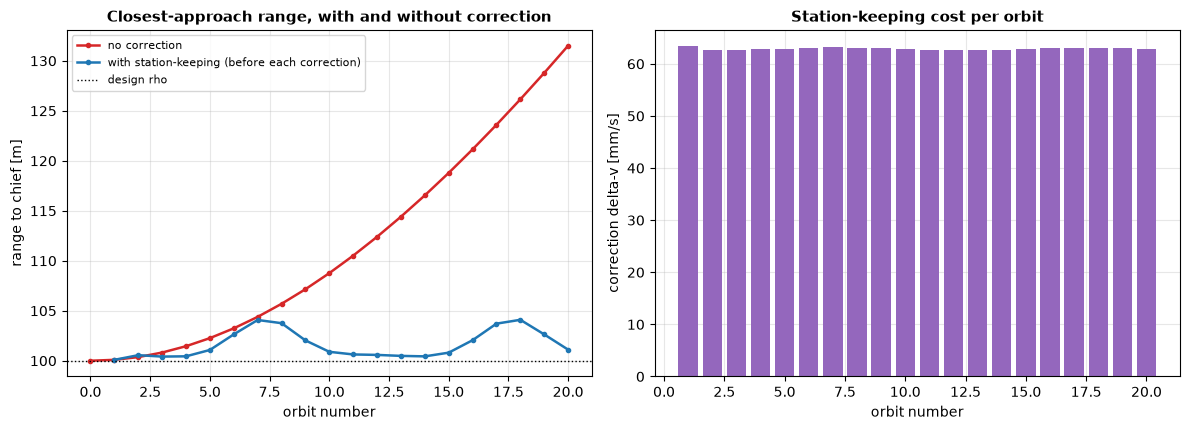

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

orbits_axis = np.arange(n_orbits + 1)
axes[0].plot(orbits_axis, ranges_uncorrected, color=COL_NUM, lw=1.8, marker="o", ms=3, label="no correction")
axes[0].plot(orbits_axis[1:], ranges_before_correction, color=COL_ANA, lw=1.8, marker="o", ms=3,
              label="with station-keeping (before each correction)")
axes[0].axhline(safety_orbit.rho, color="k", lw=1, ls=":", label="design rho")
axes[0].set_xlabel("orbit number"); axes[0].set_ylabel("range to chief [m]")
axes[0].set_title("Closest-approach range, with and without correction")
axes[0].legend(fontsize=8)

axes[1].bar(np.arange(1, n_orbits + 1), np.array(dv_per_orbit) * 1e3, color=COL_ZONE)
axes[1].set_xlabel("orbit number"); axes[1].set_ylabel("correction delta-v [mm/s]")
axes[1].set_title("Station-keeping cost per orbit")

plt.tight_layout()
plt.show()

Without correction the closest-approach range grows past 130 m within 20 orbits and keeps going; with a correction once per orbit it stays within a couple of metres of the design value, at a cost of a few tens of millimetres per second per orbit. Neither the 20 m zone from Parts A to C nor anything close to it is actually threatened in this particular geometry over this time horizon, which is itself worth stating plainly: J2 does not automatically turn a safety ellipse unsafe. It does erode the design though, and whether that erosion ever reaches a given keep-out zone depends on the ellipse's size, its orientation, and how long it is left uncorrected, so this check, not an assumption either way, is what the safety layer needs to run for whatever geometry a real mission actually plans to fly.

## Summary

A keep-out ellipsoid and `check_trajectory` give the basic yes/no and the margin to the boundary that every later check in this layer builds on. Passive safety turns that into a question about failure: does a planned burn's own failure stay harmless for long enough to react, checked by coasting the pre-burn state forward and running it through the same keep-out check. An approach corridor adds the directional constraint that distance alone misses, and the comparison in Part C shows it catches real cases that passive safety does not, and vice versa. Part D adds the time dimension: J2 slowly erodes the design of a safety ellipse through channels the linear CW model does not capture, and while it did not threaten the keep-out zone used here, correcting it is still a real, measurable delta-v cost, now in hand for the budget layer.

What is still open from the layer 2 plan: a proper collision probability on top of these deterministic checks, once navigation and burn-execution uncertainty are added; and pulling A to D together into a single pass over the actual rendezvous mission from `rendezvous_to_safety_ellipse.ipynb`, instead of the toy examples used to build each check here.